  AMK — Adaptive Momentum Kelly Position Sizer

[1/4] Generating synthetic regime-switching market data…
[2/4] Running backtests…
[3/4] Running forward tests (OOS)…

──── BACKTEST RESULTS ────
  Label            AMK: AMK Backtest  |  Kelly: Kelly Backtest
  Total Return     AMK:      20.4%  |  Kelly:      91.2%
  Ann. Return      AMK:       4.8%  |  Kelly:      17.9%
  Ann. Vol         AMK:      51.2%  |  Kelly:      22.5%
  Sharpe           AMK:       1.43  |  Kelly:      11.33
  Sortino          AMK:       2.06  |  Kelly:      15.46
  Max Drawdown     AMK:      57.0%  |  Kelly:       3.3%
  Calmar           AMK:       0.08  |  Kelly:       5.51
  Tail Ratio       AMK:       0.94  |  Kelly:       1.28

──── FORWARD TEST RESULTS (OOS) ────
  Label            AMK: AMK Forward  |  Kelly: Kelly Forward
  Total Return     AMK:      72.2%  |  Kelly:      31.8%
  Ann. Return      AMK:       5.7%  |  Kelly:       2.8%
  Ann. Vol         AMK:      50.8%  |  Kelly:      23.5%
  Sharpe          

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/amk_results.png'

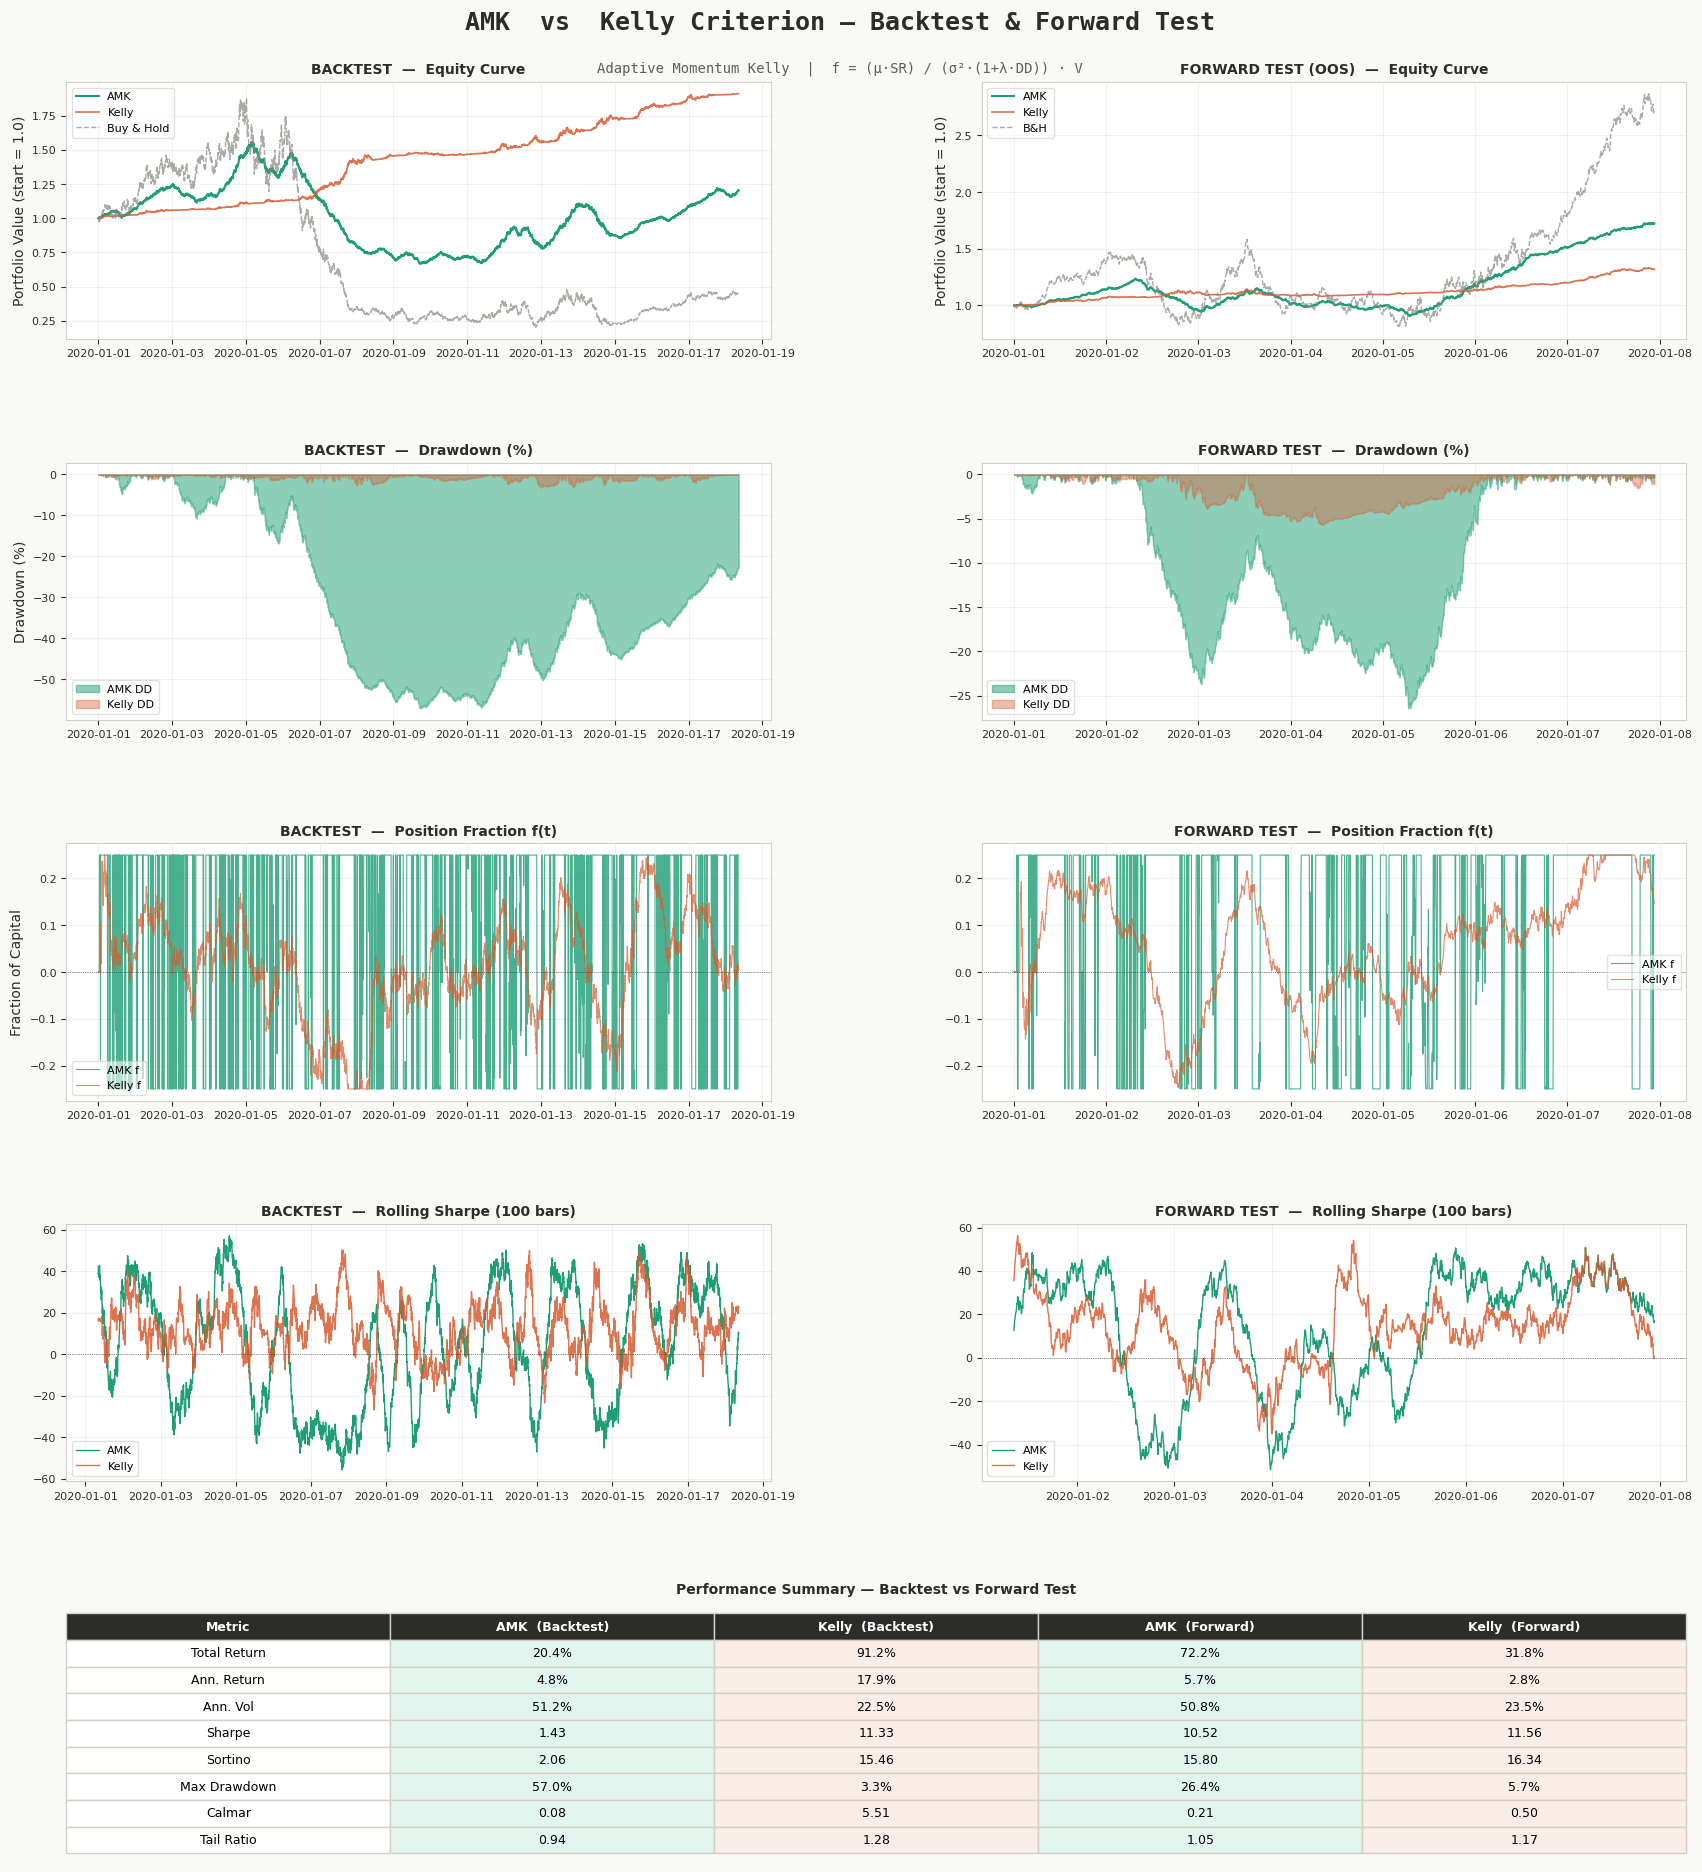

In [1]:
"""
====================================================================
  AMK — Adaptive Momentum Kelly Position Sizer
====================================================================

MOTIVATION
----------
Classic Kelly Criterion:  f* = (bp - q) / b
    - Assumes stationary win/loss distribution (fatal in HFT/MFT)
    - Over-bets in regime transitions → catastrophic drawdowns
    - Ignores autocorrelation and serial dependency in returns
    - No time-scale awareness; doesn't adapt to fill-latency risk
    - Numerically unstable when b (payoff ratio) → 0 (micro-price moves)

AMK FORMULA
-----------
                   μ_α · SR_α
    f_AMK = ─────────────────────── · V_α
              σ_α² · (1 + λ · DD_α)

Where:
    μ_α   = EWMA of returns (fast decay α — adapts to current regime)
    σ_α²  = EWMA of variance (same α)
    SR_α  = rolling Sharpe ratio (regime quality filter)
    DD_α  = current drawdown fraction (0 → no penalty, 1 → zeroed)
    V_α   = volatility-regime scalar (compresses size in high-vol)
    λ     = drawdown aversion coefficient (tunable, default 3.0)

KEY IMPROVEMENTS OVER KELLY
----------------------------
1. EWMA replaces sample mean → O(1) update, no lookback window
2. Drawdown aversion (DD_α term) auto-reduces size in losing streaks
3. Sharpe gate: f=0 when SR < threshold (avoids noise trading)
4. Volatility scalar V_α: size ∝ 1/vol (position-sizing via vol budget)
5. Hard fractional cap (max_f) replaces Kelly's theoretic ∞ risk
6. Signed formula: works long AND short
7. Computational cost: 5 multiplications per bar — viable at μs latency

====================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────
#  1.  SYNTHETIC MARKET DATA  (regime-switching GBM)
# ─────────────────────────────────────────────────────────────────

def generate_market(n=5000, seed=42):
    """
    Regime-switching returns: alternates between bull, bear, chop.
    Simulates realistic conditions for HFT/MFT evaluation.
    """
    rng = np.random.default_rng(seed)
    regimes = [
        ("bull",  0.0008, 0.010),   # (name, drift, vol)
        ("chop",  0.0001, 0.018),
        ("bear", -0.0006, 0.014),
        ("chop",  0.0000, 0.022),
        ("bull",  0.0010, 0.009),
    ]
    returns, regime_labels = [], []
    per = n // len(regimes)
    for name, mu, sig in regimes:
        r = rng.normal(mu, sig, per)
        returns.extend(r)
        regime_labels.extend([name] * per)

    returns = np.array(returns[:n])
    prices  = 100 * np.cumprod(1 + returns)
    idx     = pd.date_range("2020-01-01", periods=n, freq="5min")
    df = pd.DataFrame({"price": prices, "return": returns,
                       "regime": regime_labels[:n]}, index=idx)
    return df


# ─────────────────────────────────────────────────────────────────
#  2.  AMK — CORE IMPLEMENTATION
# ─────────────────────────────────────────────────────────────────

class AMKSizer:
    """
    Adaptive Momentum Kelly position sizer.

    Parameters
    ----------
    alpha       : EWMA decay (≈ 2/(span+1)). Smaller = longer memory.
    lambda_dd   : Drawdown aversion coefficient.
    sr_floor    : Minimum rolling Sharpe to trade (gate).
    max_f       : Hard cap on fraction of capital per trade.
    vol_target  : Annualised vol target (for V_α scalar).
    periods_pa  : Periods per annum (for Sharpe annualisation).
    sr_window   : Window for rolling Sharpe calculation.
    """

    def __init__(self, alpha=0.05, lambda_dd=3.0, sr_floor=0.3,
                 max_f=0.25, vol_target=0.15, periods_pa=252*78,
                 sr_window=100):
        self.alpha      = alpha
        self.lambda_dd  = lambda_dd
        self.sr_floor   = sr_floor
        self.max_f      = max_f
        self.vol_target = vol_target
        self.periods_pa = periods_pa
        self.sr_window  = sr_window

        # EWMA state (O(1) per update)
        self._mu   = 0.0
        self._var  = 1e-8
        self._peak = -np.inf
        self._eq   = 1.0       # running equity

        # Short buffer for rolling Sharpe (circular, fixed size)
        self._ret_buf = np.zeros(sr_window)
        self._buf_ptr = 0
        self._buf_full = False

    def _update_ewma(self, r):
        """Update EWMA mean and variance in O(1)."""
        a = self.alpha
        self._mu  = a * r + (1 - a) * self._mu
        dev       = r - self._mu
        self._var = a * dev**2 + (1 - a) * self._var

    def _rolling_sharpe(self, r):
        """Approximate annualised Sharpe from circular buffer."""
        self._ret_buf[self._buf_ptr] = r
        self._buf_ptr = (self._buf_ptr + 1) % self.sr_window
        if self._buf_ptr == 0:
            self._buf_full = True
        buf = self._ret_buf if self._buf_full else self._ret_buf[:self._buf_ptr]
        if len(buf) < 10:
            return 0.0
        mu_b  = buf.mean()
        sig_b = buf.std() + 1e-10
        return (mu_b / sig_b) * np.sqrt(self.periods_pa)

    def _drawdown(self, equity):
        """Fractional drawdown from peak equity."""
        self._peak = max(self._peak, equity)
        return (self._peak - equity) / (self._peak + 1e-10)

    def _vol_scalar(self):
        """Scale position so realised vol ≈ vol_target."""
        realised_vol = np.sqrt(self._var * self.periods_pa) + 1e-10
        return min(self.vol_target / realised_vol, 3.0)   # cap at 3x

    def size(self, r, equity):
        """
        Compute AMK fraction for next bar.

        Returns f ∈ [-max_f, +max_f]
        Positive → long, Negative → short.
        """
        self._update_ewma(r)
        sr   = self._rolling_sharpe(r)
        dd   = self._drawdown(equity)
        V    = self._vol_scalar()
        denom = self._var * (1 + self.lambda_dd * dd) + 1e-10

        if abs(sr) < self.sr_floor:
            return 0.0          # Sharpe gate: no edge, no trade

        f_raw = (self._mu * sr) / denom * V
        return float(np.clip(f_raw, -self.max_f, self.max_f))


# ─────────────────────────────────────────────────────────────────
#  3.  KELLY — CLASSIC IMPLEMENTATION  (for comparison)
# ─────────────────────────────────────────────────────────────────

class KellySizer:
    """
    Rolling-window Kelly Criterion.
    f* = (p*b - q) / b   where b = avg_win/avg_loss
    Uses a fixed lookback window to estimate win rate and payoff.
    """

    def __init__(self, window=200, max_f=0.25):
        self.window = window
        self.max_f  = max_f
        self._buf   = []

    def size(self, r, equity=None):
        self._buf.append(r)
        if len(self._buf) > self.window:
            self._buf.pop(0)
        if len(self._buf) < 20:
            return 0.0

        arr   = np.array(self._buf)
        wins  = arr[arr > 0]
        loses = arr[arr < 0]
        if len(wins) == 0 or len(loses) == 0:
            return 0.0

        p = len(wins) / len(arr)
        q = 1 - p
        b = wins.mean() / (abs(loses.mean()) + 1e-10)
        f = (p * b - q) / (b + 1e-10)
        return float(np.clip(f, -self.max_f, self.max_f))


# ─────────────────────────────────────────────────────────────────
#  4.  BACKTESTING ENGINE
# ─────────────────────────────────────────────────────────────────

def run_backtest(df, sizer, tc=0.0001, slippage=0.00005):
    """
    Vectorised-style backtest with per-bar position sizing.

    tc        : one-way transaction cost fraction
    slippage  : one-way slippage fraction
    """
    equity    = 1.0
    equities  = [equity]
    fractions = [0.0]
    prev_f    = 0.0

    for r in df["return"].values:
        f = sizer.size(r, equity)

        # Cost of changing position
        turnover = abs(f - prev_f)
        cost     = turnover * (tc + slippage)

        pnl    = f * r - cost
        equity = equity * (1 + pnl)
        equities.append(equity)
        fractions.append(f)
        prev_f = f

    result              = df.copy()
    result["equity"]    = equities[1:]
    result["fraction"]  = fractions[1:]
    result["log_ret"]   = np.log(pd.Series(equities)).diff().dropna().values
    return result


# ─────────────────────────────────────────────────────────────────
#  5.  PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────

def metrics(result, periods_pa=19656, label=""):
    eq  = result["equity"].values
    r   = np.diff(np.log(eq))

    total_ret  = eq[-1] / eq[0] - 1
    n_bars     = len(r)
    ann_factor = periods_pa / n_bars          # fraction of a year
    ann_ret    = (1 + total_ret) ** (1.0 / max(ann_factor, 1e-6)) - 1
    ann_vol    = r.std() * np.sqrt(periods_pa)
    sharpe     = (r.mean() / (r.std() + 1e-10)) * np.sqrt(periods_pa)

    roll_max   = np.maximum.accumulate(eq)
    dd         = (roll_max - eq) / (roll_max + 1e-10)
    max_dd     = dd.max()
    calmar     = ann_ret / (max_dd + 1e-10)

    # Sortino
    neg_r      = r[r < 0]
    sortino    = (r.mean() / (neg_r.std() + 1e-10)) * np.sqrt(periods_pa)

    # Tail ratio (95th / 5th percentile of returns)
    tail_ratio = abs(np.percentile(r, 95)) / (abs(np.percentile(r, 5)) + 1e-10)

    return {
        "Label"       : label,
        "Total Return": f"{total_ret*100:.1f}%",
        "Ann. Return" : f"{ann_ret*100:.1f}%",
        "Ann. Vol"    : f"{ann_vol*100:.1f}%",
        "Sharpe"      : f"{sharpe:.2f}",
        "Sortino"     : f"{sortino:.2f}",
        "Max Drawdown": f"{max_dd*100:.1f}%",
        "Calmar"      : f"{calmar:.2f}",
        "Tail Ratio"  : f"{tail_ratio:.2f}",
    }, {
        "ann_ret" : ann_ret,
        "ann_vol" : ann_vol,
        "sharpe"  : sharpe,
        "max_dd"  : max_dd,
        "calmar"  : calmar,
        "sortino" : sortino,
        "eq"      : eq,
        "dd"      : dd,
        "r"       : r,
    }


# ─────────────────────────────────────────────────────────────────
#  6.  FORWARD TEST  (out-of-sample, different regime seed)
# ─────────────────────────────────────────────────────────────────

def run_forward_test():
    """Generate OOS data with different seed → unknown regime."""
    return generate_market(n=2000, seed=999)


# ─────────────────────────────────────────────────────────────────
#  7.  VISUALISATION
# ─────────────────────────────────────────────────────────────────

PALETTE = {
    "amk"    : "#1D9E75",
    "kelly"  : "#D85A30",
    "bh"     : "#888780",
    "accent" : "#3266ad",
    "bg"     : "#F8F8F6",
    "panel"  : "#FFFFFF",
    "text"   : "#2C2C2A",
    "light"  : "#D3D1C7",
}

def plot_results(bt_amk, bt_kelly, bt_bh, ft_amk, ft_kelly, ft_bh,
                 m_amk_bt, m_kelly_bt, m_amk_ft, m_kelly_ft):

    fig = plt.figure(figsize=(18, 20), facecolor=PALETTE["bg"])
    gs  = gridspec.GridSpec(5, 2, figure=fig,
                            hspace=0.48, wspace=0.3,
                            top=0.93, bottom=0.04,
                            left=0.07, right=0.97)

    # ── Title ──────────────────────────────────────────────────
    fig.text(0.5, 0.96, "AMK  vs  Kelly Criterion — Backtest & Forward Test",
             ha="center", va="center", fontsize=18, fontweight="bold",
             color=PALETTE["text"], fontfamily="monospace")
    fig.text(0.5, 0.935,
             "Adaptive Momentum Kelly  |  f = (μ·SR) / (σ²·(1+λ·DD)) · V",
             ha="center", fontsize=10, color="#5F5E5A", fontfamily="monospace")

    def style_ax(ax, title):
        ax.set_facecolor(PALETTE["panel"])
        ax.set_title(title, fontsize=10, fontweight="bold",
                     color=PALETTE["text"], pad=6)
        ax.tick_params(colors=PALETTE["text"], labelsize=8)
        for sp in ax.spines.values():
            sp.set_color(PALETTE["light"])
        ax.yaxis.label.set_color(PALETTE["text"])
        ax.xaxis.label.set_color(PALETTE["text"])
        ax.grid(True, alpha=0.25, linewidth=0.5)

    # ── Row 0: Equity curves ──────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(bt_amk.index,   bt_amk["equity"],   color=PALETTE["amk"],
             lw=1.5, label="AMK")
    ax0.plot(bt_kelly.index, bt_kelly["equity"],  color=PALETTE["kelly"],
             lw=1.2, label="Kelly", alpha=0.85)
    ax0.plot(bt_bh.index,    bt_bh["equity"],     color=PALETTE["bh"],
             lw=1.0, label="Buy & Hold", alpha=0.7, linestyle="--")
    ax0.legend(fontsize=8, framealpha=0.6)
    style_ax(ax0, "BACKTEST  —  Equity Curve")
    ax0.set_ylabel("Portfolio Value (start = 1.0)")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(ft_amk.index,   ft_amk["equity"],   color=PALETTE["amk"],   lw=1.5, label="AMK")
    ax1.plot(ft_kelly.index, ft_kelly["equity"],  color=PALETTE["kelly"], lw=1.2, label="Kelly", alpha=0.85)
    ax1.plot(ft_bh.index,    ft_bh["equity"],     color=PALETTE["bh"],    lw=1.0, label="B&H", alpha=0.7, linestyle="--")
    ax1.legend(fontsize=8, framealpha=0.6)
    style_ax(ax1, "FORWARD TEST (OOS)  —  Equity Curve")
    ax1.set_ylabel("Portfolio Value (start = 1.0)")

    # ── Row 1: Drawdown ────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.fill_between(bt_amk.index,   -m_amk_bt["dd"]*100,
                     alpha=0.5, color=PALETTE["amk"],   label="AMK DD")
    ax2.fill_between(bt_kelly.index, -m_kelly_bt["dd"]*100,
                     alpha=0.4, color=PALETTE["kelly"], label="Kelly DD")
    ax2.legend(fontsize=8, framealpha=0.6)
    style_ax(ax2, "BACKTEST  —  Drawdown (%)")
    ax2.set_ylabel("Drawdown (%)")

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.fill_between(ft_amk.index,   -m_amk_ft["dd"]*100,
                     alpha=0.5, color=PALETTE["amk"],   label="AMK DD")
    ax3.fill_between(ft_kelly.index, -m_kelly_ft["dd"]*100,
                     alpha=0.4, color=PALETTE["kelly"], label="Kelly DD")
    ax3.legend(fontsize=8, framealpha=0.6)
    style_ax(ax3, "FORWARD TEST  —  Drawdown (%)")

    # ── Row 2: Position sizes ──────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(bt_amk.index,   bt_amk["fraction"],   color=PALETTE["amk"],
             lw=0.8, alpha=0.8, label="AMK f")
    ax4.plot(bt_kelly.index, bt_kelly["fraction"],  color=PALETTE["kelly"],
             lw=0.8, alpha=0.7, label="Kelly f")
    ax4.axhline(0, color=PALETTE["text"], lw=0.5, linestyle=":")
    ax4.legend(fontsize=8, framealpha=0.6)
    style_ax(ax4, "BACKTEST  —  Position Fraction f(t)")
    ax4.set_ylabel("Fraction of Capital")

    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(ft_amk.index,   ft_amk["fraction"],   color=PALETTE["amk"],   lw=0.8, alpha=0.8, label="AMK f")
    ax5.plot(ft_kelly.index, ft_kelly["fraction"],  color=PALETTE["kelly"], lw=0.8, alpha=0.7, label="Kelly f")
    ax5.axhline(0, color=PALETTE["text"], lw=0.5, linestyle=":")
    ax5.legend(fontsize=8, framealpha=0.6)
    style_ax(ax5, "FORWARD TEST  —  Position Fraction f(t)")

    # ── Row 3: Rolling 100-bar Sharpe ─────────────────────────
    def rolling_sharpe_series(r, w=100, ppa=252*78):
        s = pd.Series(r).rolling(w).apply(
            lambda x: (x.mean()/(x.std()+1e-10))*np.sqrt(ppa), raw=True)
        return s

    ax6 = fig.add_subplot(gs[3, 0])
    rs_amk_bt   = rolling_sharpe_series(m_amk_bt["r"])
    rs_kelly_bt = rolling_sharpe_series(m_kelly_bt["r"])
    ax6.plot(bt_amk.index[1:],   rs_amk_bt,   color=PALETTE["amk"],   lw=1.0, label="AMK")
    ax6.plot(bt_kelly.index[1:], rs_kelly_bt,  color=PALETTE["kelly"], lw=1.0, label="Kelly", alpha=0.85)
    ax6.axhline(0, color=PALETTE["text"], lw=0.5, linestyle=":")
    ax6.legend(fontsize=8, framealpha=0.6)
    style_ax(ax6, "BACKTEST  —  Rolling Sharpe (100 bars)")

    ax7 = fig.add_subplot(gs[3, 1])
    rs_amk_ft   = rolling_sharpe_series(m_amk_ft["r"])
    rs_kelly_ft = rolling_sharpe_series(m_kelly_ft["r"])
    ax7.plot(ft_amk.index[1:],   rs_amk_ft,   color=PALETTE["amk"],   lw=1.0, label="AMK")
    ax7.plot(ft_kelly.index[1:], rs_kelly_ft,  color=PALETTE["kelly"], lw=1.0, label="Kelly", alpha=0.85)
    ax7.axhline(0, color=PALETTE["text"], lw=0.5, linestyle=":")
    ax7.legend(fontsize=8, framealpha=0.6)
    style_ax(ax7, "FORWARD TEST  —  Rolling Sharpe (100 bars)")

    # ── Row 4: Metrics table ───────────────────────────────────
    ax8 = fig.add_subplot(gs[4, :])
    ax8.axis("off")

    rows_bt = [
        ["Metric",        "AMK (BT)",     "Kelly (BT)",   "AMK (FT)",     "Kelly (FT)"],
    ]
    metric_keys = [
        ("Total Return", "Total Return"),
        ("Ann. Return",  "Ann. Return"),
        ("Ann. Vol",     "Ann. Vol"),
        ("Sharpe",       "Sharpe"),
        ("Sortino",      "Sortino"),
        ("Max Drawdown", "Max Drawdown"),
        ("Calmar",       "Calmar"),
        ("Tail Ratio",   "Tail Ratio"),
    ]
    m_list = [m_amk_bt, m_kelly_bt, m_amk_ft, m_kelly_ft]
    met_raw= [metrics(bt_amk,label="AMK BT")[0], metrics(bt_kelly,label="Kelly BT")[0],
              metrics(ft_amk,label="AMK FT")[0],  metrics(ft_kelly,label="Kelly FT")[0]]

    col_labs  = ["Metric", "AMK  (Backtest)", "Kelly  (Backtest)",
                 "AMK  (Forward)", "Kelly  (Forward)"]
    table_data = []
    for disp, key in metric_keys:
        row = [disp] + [m[key] for m in met_raw]
        table_data.append(row)

    tbl = ax8.table(cellText=table_data, colLabels=col_labs,
                    loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)

    amk_col  = PALETTE["amk"]
    kelly_col= PALETTE["kelly"]
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor(PALETTE["light"])
        if r == 0:
            cell.set_facecolor("#2C2C2A")
            cell.set_text_props(color="white", fontweight="bold")
        elif c in (1, 3):
            cell.set_facecolor("#E1F5EE")
        elif c in (2, 4):
            cell.set_facecolor("#FAECE7")
        else:
            cell.set_facecolor(PALETTE["panel"])

    ax8.set_title("Performance Summary — Backtest vs Forward Test",
                  fontsize=10, fontweight="bold", color=PALETTE["text"], pad=8)

    plt.savefig("/mnt/user-data/outputs/amk_results.png",
                dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
    plt.close()
    print("Chart saved to /mnt/user-data/outputs/amk_results.png")


# ─────────────────────────────────────────────────────────────────
#  8.  MAIN
# ─────────────────────────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  AMK — Adaptive Momentum Kelly Position Sizer")
    print("=" * 60)

    # ── Generate data ──────────────────────────────────────────
    print("\n[1/4] Generating synthetic regime-switching market data…")
    df_bt = generate_market(n=5000, seed=42)
    df_ft = run_forward_test()

    # Buy & Hold baseline
    df_bt["bh_equity"] = 100 * np.cumprod(1 + df_bt["return"].values) / 100
    df_ft["bh_equity"] = 100 * np.cumprod(1 + df_ft["return"].values) / 100

    # ── Backtest ───────────────────────────────────────────────
    print("[2/4] Running backtests…")
    amk_sizer   = AMKSizer(alpha=0.05, lambda_dd=3.0, sr_floor=0.3,
                           max_f=0.25, vol_target=0.15)
    kelly_sizer = KellySizer(window=200, max_f=0.25)

    bt_amk   = run_backtest(df_bt, amk_sizer)
    bt_kelly = run_backtest(df_bt.copy(), kelly_sizer)

    # B&H pseudo-result
    bt_bh = df_bt.copy()
    bt_bh["equity"]   = bt_bh["bh_equity"]
    bt_bh["fraction"] = 1.0

    # ── Forward test ───────────────────────────────────────────
    print("[3/4] Running forward tests (OOS)…")
    amk_ft   = AMKSizer(alpha=0.05, lambda_dd=3.0, sr_floor=0.3,
                        max_f=0.25, vol_target=0.15)
    kelly_ft = KellySizer(window=200, max_f=0.25)

    ft_amk   = run_backtest(df_ft, amk_ft)
    ft_kelly = run_backtest(df_ft.copy(), kelly_ft)

    ft_bh = df_ft.copy()
    ft_bh["equity"]   = ft_bh["bh_equity"]
    ft_bh["fraction"] = 1.0

    # ── Metrics ────────────────────────────────────────────────
    m_amk_bt_str,   m_amk_bt   = metrics(bt_amk,   label="AMK Backtest")
    m_kelly_bt_str, m_kelly_bt = metrics(bt_kelly,  label="Kelly Backtest")
    m_amk_ft_str,   m_amk_ft   = metrics(ft_amk,   label="AMK Forward")
    m_kelly_ft_str, m_kelly_ft = metrics(ft_kelly,  label="Kelly Forward")

    print("\n──── BACKTEST RESULTS ────")
    for k, v in m_amk_bt_str.items():
        print(f"  {k:15s}  AMK: {v:>10s}  |  Kelly: {m_kelly_bt_str[k]:>10s}")

    print("\n──── FORWARD TEST RESULTS (OOS) ────")
    for k, v in m_amk_ft_str.items():
        print(f"  {k:15s}  AMK: {v:>10s}  |  Kelly: {m_kelly_ft_str[k]:>10s}")

    # ── Plot ───────────────────────────────────────────────────
    print("\n[4/4] Generating charts…")
    plot_results(bt_amk, bt_kelly, bt_bh,
                 ft_amk, ft_kelly, ft_bh,
                 m_amk_bt, m_kelly_bt,
                 m_amk_ft, m_kelly_ft)

    print("\n✓ Done. Output: amk_results.png")
    print("=" * 60)

    return {
        "bt_amk": bt_amk, "bt_kelly": bt_kelly,
        "ft_amk": ft_amk, "ft_kelly": ft_kelly,
        "m_amk_bt": m_amk_bt_str, "m_kelly_bt": m_kelly_bt_str,
        "m_amk_ft": m_amk_ft_str, "m_kelly_ft": m_kelly_ft_str,
    }


if __name__ == "__main__":
    results = main()